In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []   

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        for epoch in range(self.epochs):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = self.activation(linear_output)

            errors = y - y_pred

            loss = np.sum(errors**2)
            self.losses.append(loss)

            # update weights
            self.weights += self.lr * np.dot(X.T, errors)
            self.bias += self.lr * np.sum(errors)

    def predict(self, X):
        X = np.array(X)
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)

Predictions: [0 0 0 1]
Accuracy: 1.00


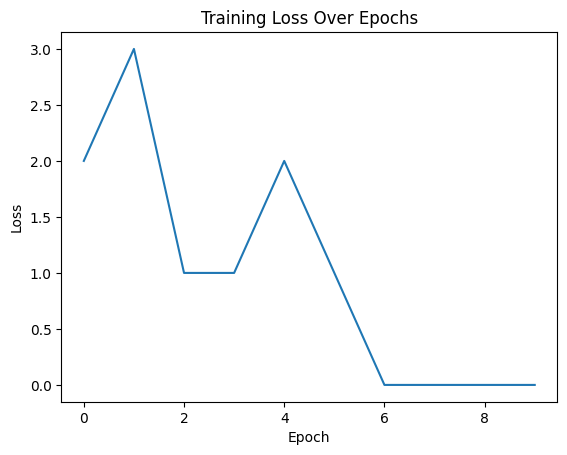

In [26]:
data = {
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    'y': [0, 0, 0, 1]
}

df = pd.DataFrame(data)

X = df[['x1', 'x2']]
y = df['y']

model = Perceptron(lr=0.1, epochs=10)
model.fit(X, y)

preds = model.predict(X)
accuracy = model.accuracy(y, preds)

print(f"Predictions: {preds}")
print(f"Accuracy: {accuracy:.2f}")

plt.plot(model.losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()